# Mérési notebook
---
# **1. mérési fázis**. A	Modellek tesztelése tanítás nélkül.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

---

## EREDMÉNYEK ÖSSZEGZÉSE

---



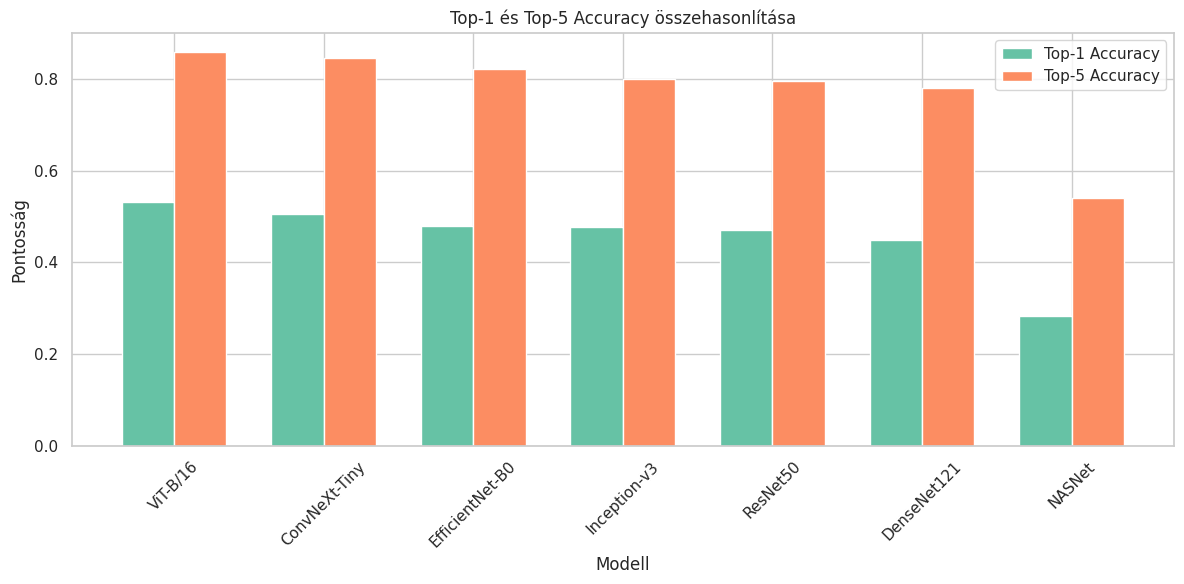

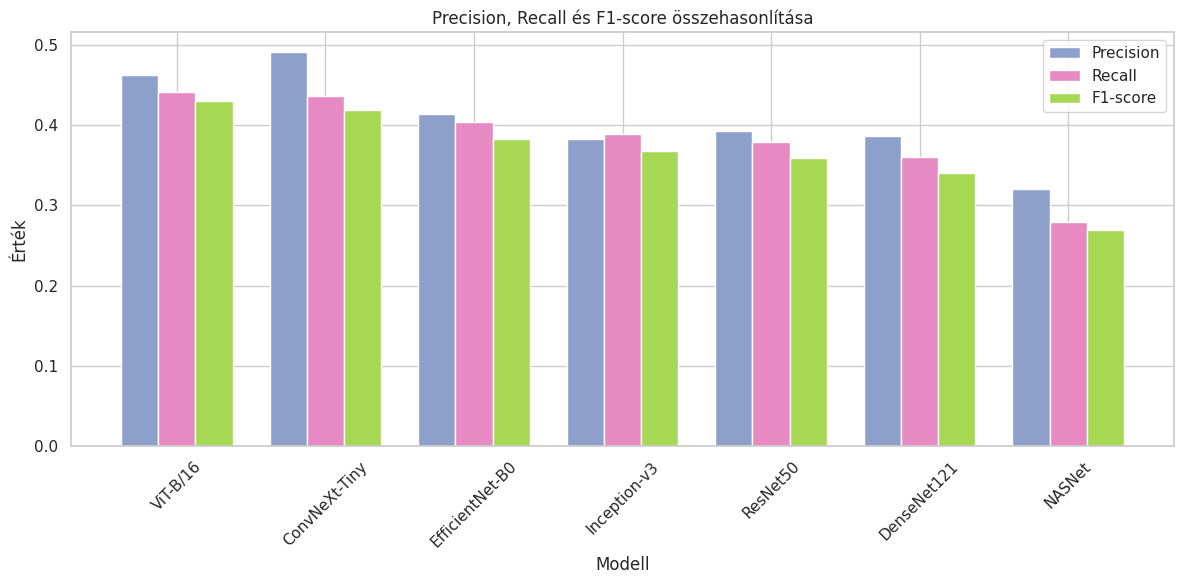

<ipython-input-1-9907b89ef354>:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modell', y='Inference Time (s)', data=df_sorted, palette=palette)
<ipython-input-1-9907b89ef354>:56: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.barplot(x='Modell', y='Inference Time (s)', data=df_sorted, palette=palette)


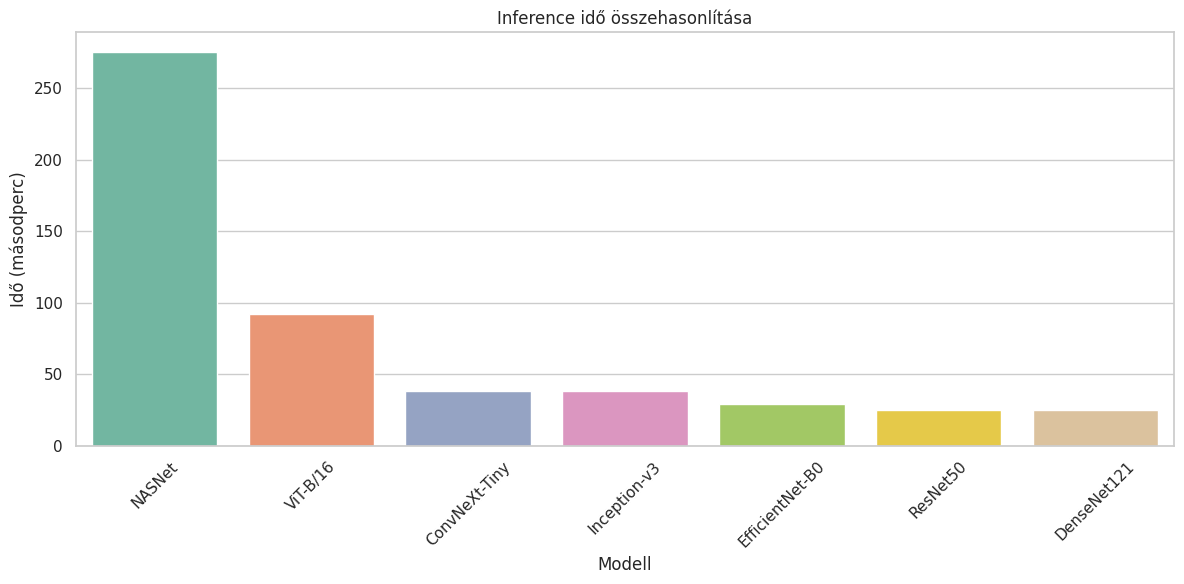

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Adatok betöltése
data = {
    'Modell': ['ResNet50', 'DenseNet121', 'EfficientNet-B0', 'ConvNeXt-Tiny', 'ViT-B/16', 'Inception-v3', 'NASNet'],
    'Top-1 Accuracy': [0.4698, 0.4498, 0.4802, 0.5048, 0.5308, 0.4763, 0.2820],
    'Top-5 Accuracy': [0.7962, 0.7806, 0.8217, 0.8471, 0.8582, 0.8008, 0.5408],
    'Precision': [0.3934, 0.3874, 0.4137, 0.4917, 0.4629, 0.3833, 0.3204],
    'Recall': [0.3797, 0.3611, 0.4039, 0.4369, 0.4419, 0.3896, 0.2799],
    'F1-score': [0.3592, 0.3408, 0.3829, 0.4194, 0.4307, 0.3683, 0.2696],
    'Inference Time (s)': [25.21, 25.15, 28.89, 38.40, 92.13, 38.06, 275.30]
}

df = pd.DataFrame(data)

# Stílus beállítása
sns.set(style="whitegrid")
palette = sns.color_palette("Set2")

# Top-1 és Top-5 Accuracy
plt.figure(figsize=(12, 6))
df_sorted = df.sort_values('Top-1 Accuracy', ascending=False)
bar_width = 0.35
index = range(len(df_sorted))
plt.bar(index, df_sorted['Top-1 Accuracy'], bar_width, label='Top-1 Accuracy', color=palette[0])
plt.bar([i + bar_width for i in index], df_sorted['Top-5 Accuracy'], bar_width, label='Top-5 Accuracy', color=palette[1])
plt.xlabel('Modell')
plt.ylabel('Pontosság')
plt.title('Top-1 és Top-5 Accuracy összehasonlítása')
plt.xticks([i + bar_width / 2 for i in index], df_sorted['Modell'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Precision, Recall, F1-score
plt.figure(figsize=(12, 6))
df_sorted = df.sort_values('F1-score', ascending=False)
bar_width = 0.25
index = range(len(df_sorted))
plt.bar(index, df_sorted['Precision'], bar_width, label='Precision', color=palette[2])
plt.bar([i + bar_width for i in index], df_sorted['Recall'], bar_width, label='Recall', color=palette[3])
plt.bar([i + 2 * bar_width for i in index], df_sorted['F1-score'], bar_width, label='F1-score', color=palette[4])
plt.xlabel('Modell')
plt.ylabel('Érték')
plt.title('Precision, Recall és F1-score összehasonlítása')
plt.xticks([i + bar_width for i in index], df_sorted['Modell'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Inference idő
plt.figure(figsize=(12, 6))
df_sorted = df.sort_values('Inference Time (s)', ascending=False)
sns.barplot(x='Modell', y='Inference Time (s)', data=df_sorted, palette=palette)
plt.title('Inference idő összehasonlítása')
plt.ylabel('Idő (másodperc)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


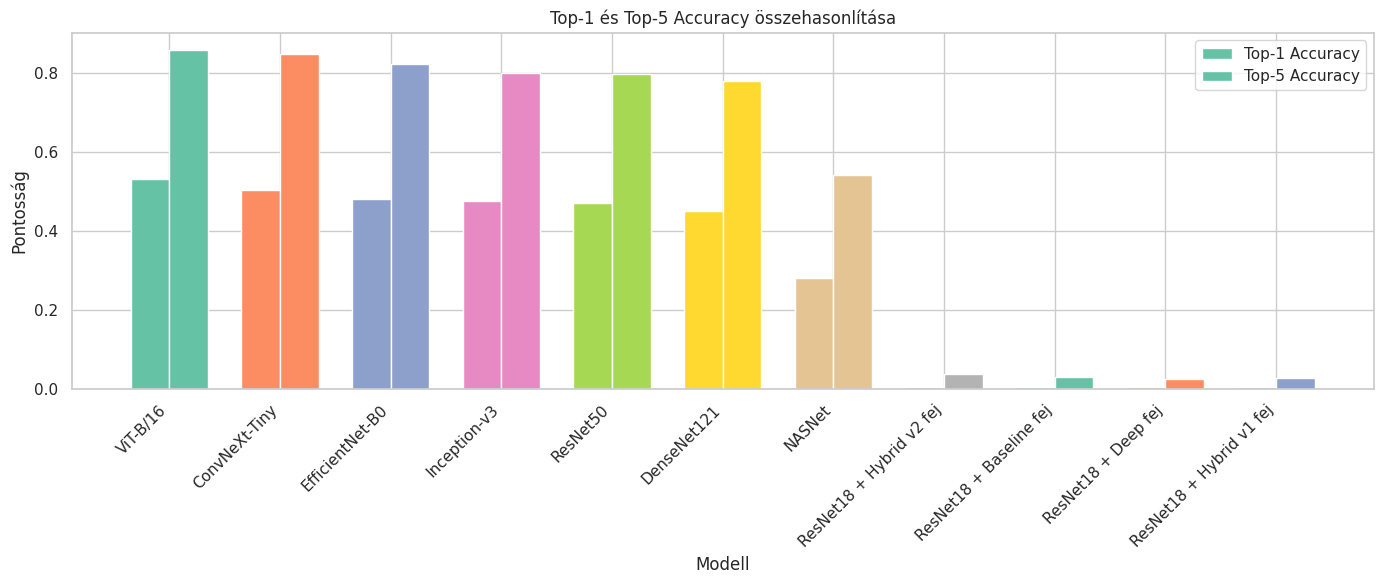

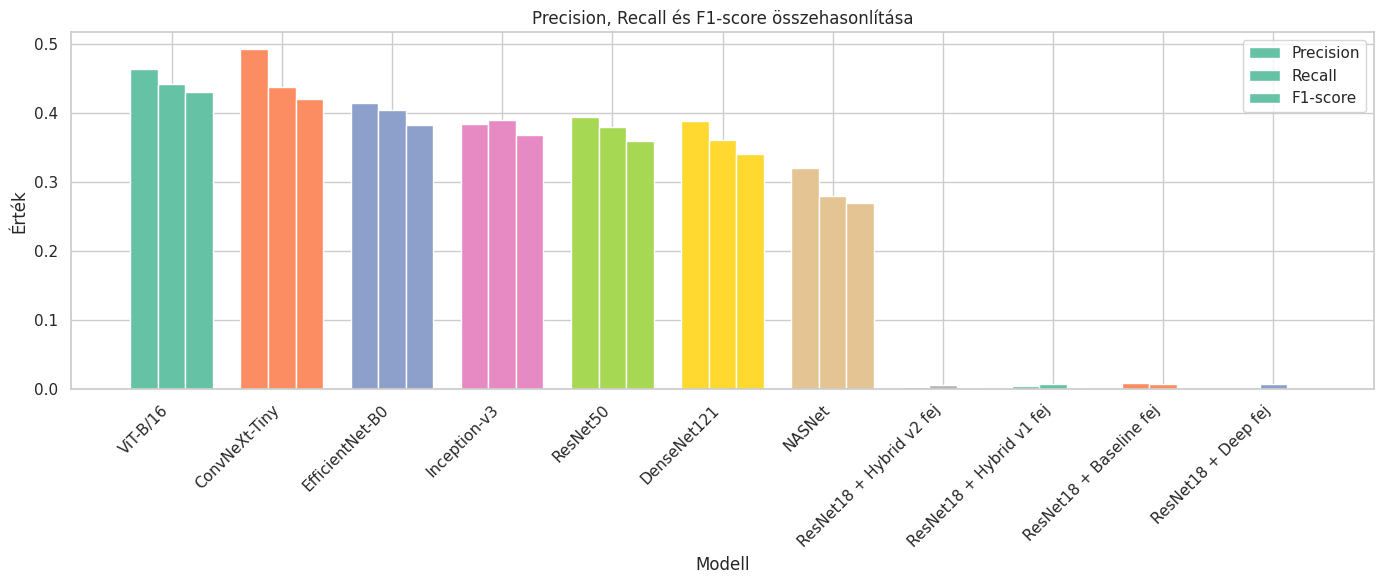

<ipython-input-2-31cf7deadd6d>:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modell', y='Inference Time (s)', data=df_sorted, palette=palette)


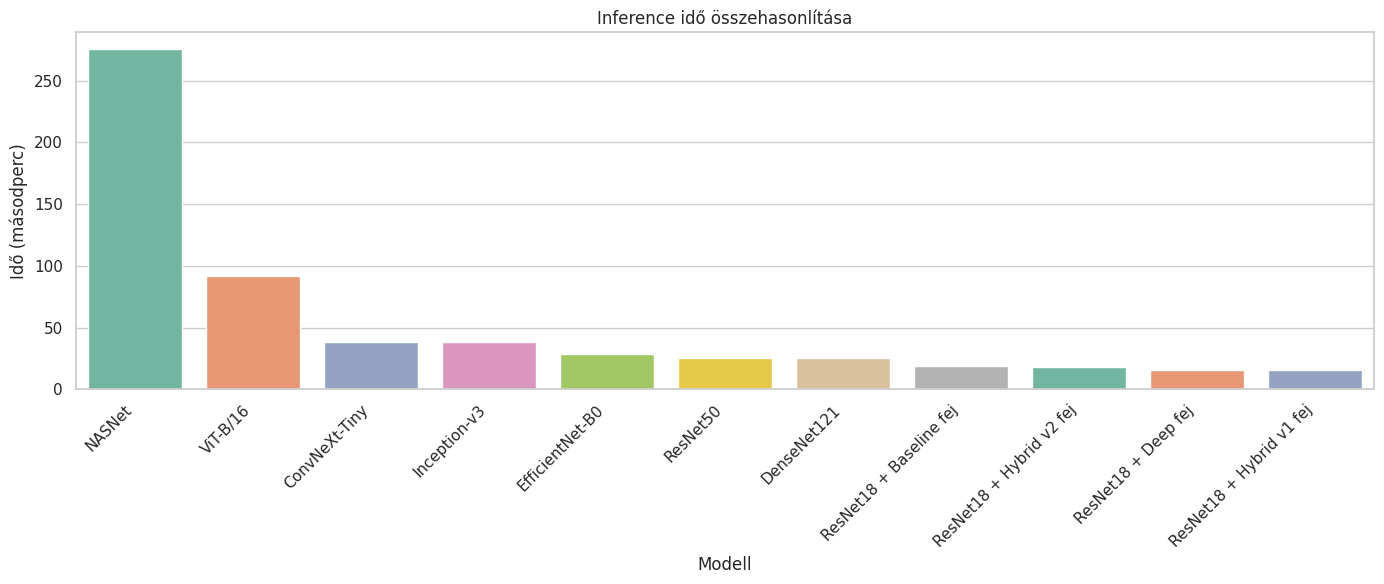

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Adatok betöltése
data = {
    'Modell': [
        'ResNet50', 'DenseNet121', 'EfficientNet-B0', 'ConvNeXt-Tiny', 'ViT-B/16',
        'Inception-v3', 'NASNet',
        'ResNet18 + Baseline fej', 'ResNet18 + Deep fej',
        'ResNet18 + Hybrid v1 fej', 'ResNet18 + Hybrid v2 fej'
    ],
    'Top-1 Accuracy': [0.4698, 0.4498, 0.4802, 0.5048, 0.5308, 0.4763, 0.2820,
                       0.0052, 0.0050, 0.0047, 0.0054],
    'Top-5 Accuracy': [0.7962, 0.7806, 0.8217, 0.8471, 0.8582, 0.8008, 0.5408,
                       0.0304, 0.0265, 0.0286, 0.0379],
    'Precision': [0.3934, 0.3874, 0.4137, 0.4917, 0.4629, 0.3833, 0.3204,
                  0.0093, 0.0003, 0.0041, 0.0026],
    'Recall': [0.3797, 0.3611, 0.4039, 0.4369, 0.4419, 0.3896, 0.2799,
               0.0072, 0.0071, 0.0076, 0.0063],
    'F1-score': [0.3592, 0.3408, 0.3829, 0.4194, 0.4307, 0.3683, 0.2696,
                 0.0011, 0.0006, 0.0014, 0.0020],
    'Inference Time (s)': [25.21, 25.15, 28.89, 38.40, 92.13, 38.06, 275.30,
                           18.48, 15.54, 15.54, 17.89]
}

df = pd.DataFrame(data)

# Stílus beállítása
sns.set(style="whitegrid")
palette = sns.color_palette("Set2", n_colors=len(df))

# Top-1 és Top-5 Accuracy
plt.figure(figsize=(14, 6))
df_sorted = df.sort_values('Top-1 Accuracy', ascending=False)
bar_width = 0.35
index = np.arange(len(df_sorted))
plt.bar(index, df_sorted['Top-1 Accuracy'], bar_width, label='Top-1 Accuracy', color=palette)
plt.bar(index + bar_width, df_sorted['Top-5 Accuracy'], bar_width, label='Top-5 Accuracy', color=palette)
plt.xlabel('Modell')
plt.ylabel('Pontosság')
plt.title('Top-1 és Top-5 Accuracy összehasonlítása')
plt.xticks(index + bar_width / 2, df_sorted['Modell'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Precision, Recall, F1-score
plt.figure(figsize=(14, 6))
df_sorted = df.sort_values('F1-score', ascending=False)
bar_width = 0.25
index = np.arange(len(df_sorted))
plt.bar(index, df_sorted['Precision'], bar_width, label='Precision', color=palette)
plt.bar(index + bar_width, df_sorted['Recall'], bar_width, label='Recall', color=palette)
plt.bar(index + 2 * bar_width, df_sorted['F1-score'], bar_width, label='F1-score', color=palette)
plt.xlabel('Modell')
plt.ylabel('Érték')
plt.title('Precision, Recall és F1-score összehasonlítása')
plt.xticks(index + bar_width, df_sorted['Modell'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Inference idő
plt.figure(figsize=(14, 6))
df_sorted = df.sort_values('Inference Time (s)', ascending=False)
sns.barplot(x='Modell', y='Inference Time (s)', data=df_sorted, palette=palette)
plt.title('Inference idő összehasonlítása')
plt.ylabel('Idő (másodperc)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
